In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Import the dataset

In [ ]:
df=pd.read_csv("/content/mental_tiredness_score_prediction_dataset.csv.csv")

#Understand the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number_of_decisions_made  15000 non-null  int64  
 1   context_switch_count      15000 non-null  int64  
 2   notifications_received    15000 non-null  int64  
 3   screen_time_min           15000 non-null  float64
 4   deep_work_min             15000 non-null  float64
 5   task_complexity_avg       15000 non-null  float64
 6   caffeine_mg               15000 non-null  float64
 7   break_frequency           15000 non-null  int64  
 8   sleep_hours               15000 non-null  float64
 9   deep_sleep_pct            15000 non-null  float64
 10  hydration_l               15000 non-null  float64
 11  mood                      15000 non-null  object 
 12  work_type                 15000 non-null  object 
 13  work_environment          15000 non-null  object 
 14  noise_

In [ ]:
df.shape

(15000, 18)

In [ ]:
df.head()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [ ]:
# let us describe the data
df.describe()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,noise_level_db,temperature_c,workload_score,mental_tiredness_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,120.079133,7.982133,64.96780,302.211107,96.698407,5.505333,131.170247,4.001733,6.893889,19.017639,1.892743,47.925353,23.000160,5.697280,25.189109
std,10.882327,2.837784,8.11442,136.575167,61.249273,1.957174,79.542710,2.017358,1.296186,5.958026,0.686356,9.880337,2.967518,1.941123,12.190013
min,82.000000,0.000000,30.00000,20.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.300000,20.000000,15.000000,1.000000,0.000000
25%,113.000000,6.000000,59.00000,205.300000,50.100000,4.175000,72.200000,3.000000,6.010000,15.040000,1.430000,41.300000,21.000000,4.400000,16.690000
50%,120.000000,8.000000,65.00000,302.000000,94.800000,5.500000,129.000000,4.000000,6.900000,18.980000,1.890000,47.900000,23.000000,5.700000,25.220000
75%,127.000000,10.000000,70.00000,396.100000,138.800000,6.800000,185.500000,5.000000,7.780000,23.062500,2.350000,54.600000,25.000000,7.000000,33.460000
max,165.000000,21.000000,101.00000,852.200000,312.800000,10.000000,422.900000,13.000000,11.000000,41.380000,4.570000,84.800000,35.000000,10.000000,76.740000


->work_environment and noise_level_db represents the same kind of information where, one gives the information in categorical form and other in the continuous numercial form.

->As the target variable is continuous numercial we go with the noise_level_db

In [ ]:
df.drop(columns=['work_environment'],inplace=True)

#Check missing values

In [ ]:
df.isnull().sum()

,0
number_of_decisions_made,0
context_switch_count,0
notifications_received,0
screen_time_min,0
deep_work_min,0
task_complexity_avg,0
caffeine_mg,0
break_frequency,0
sleep_hours,0
deep_sleep_pct,0


#Check duplicate records

In [ ]:
df.duplicated().sum()

np.int64(0)

#Exploratory Data Analysis

 Distribution of the Target Variable (mental_tiredness_score)


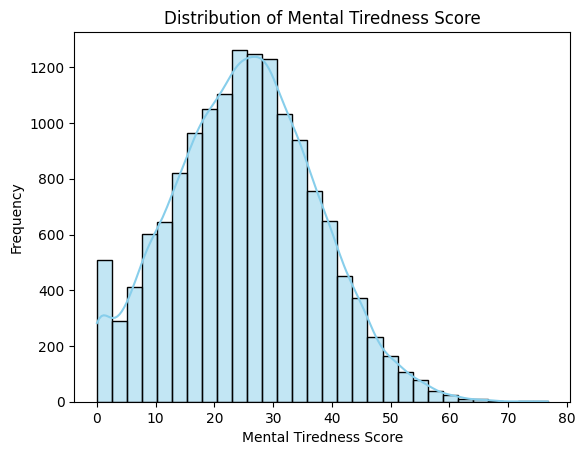

In [ ]:
sns.histplot(df['mental_tiredness_score'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Mental Tiredness Score')
plt.xlabel('Mental Tiredness Score')
plt.ylabel('Frequency')
plt.show()

observation:

->The distribution is a right-skewed distribution where the majority of  score is between 20 to 40.

->This helps us in understanding the level of tiredness, most of the people are experiencing moderate tiredness.



#Distribution of Screen Time in Minutes

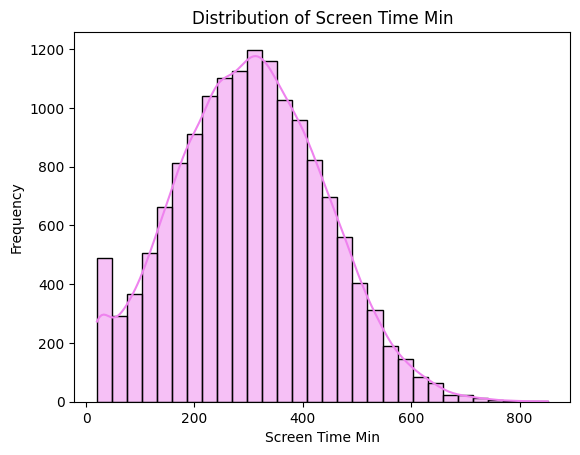

In [ ]:
sns.histplot(df['screen_time_min'], kde=True, bins=30, color='violet')
plt.title('Distribution of Screen Time Min')
plt.xlabel('Screen Time Min')
plt.ylabel('Frequency')
plt.show()

observation:

->Most values group between 200 to 400 minutes,it contains outliers as the tail stretches up to 800+ mins

->we can notice a intial spike occurance which is below 50 mins.

#Distribution of work type

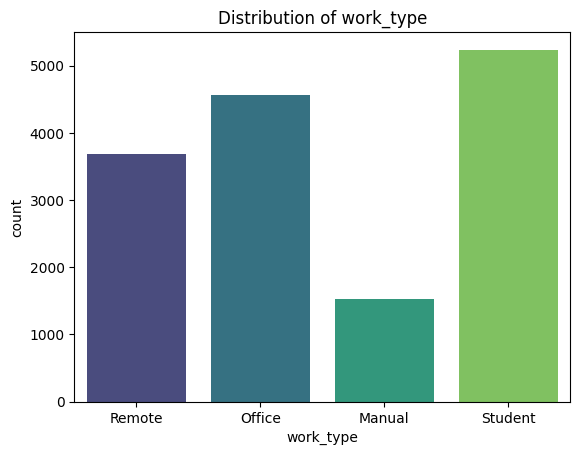

In [ ]:
sns.countplot(data=df,x='work_type',palette="viridis",hue="work_type")
plt.title("Distribution of work_type")
plt.show()

OBSERVATION:

->The student type is the most repeated one in the work type, this shows the imbalanced distribution.

->Some work type categories are heavily represented, while others are less common.

->Understanding the distribution of the categories is important as it tells us which work types belongs the majority of the data.


#Distribution of Mood

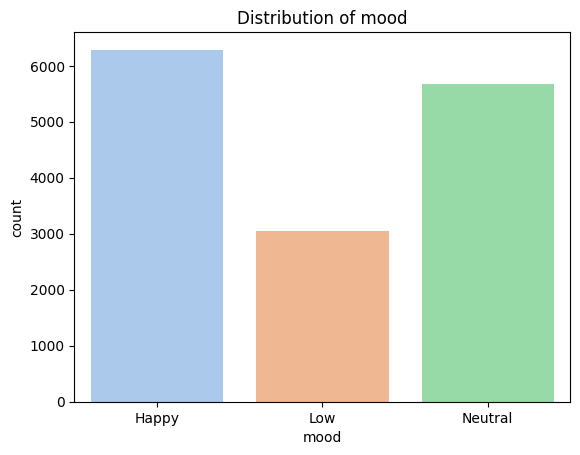

In [ ]:
sns.countplot(data=df,x='mood',palette="pastel",hue="mood")
plt.title("Distribution of mood")
plt.show()

OBSERVATION:

->Happy is the largest group with over 6,000 counts which means , over 40% of observations fall into the "Happy" category , making it the most dominant mood state in the dataset.

#Bi-Variate Analysis

#Sleep VS Mental_Tiredness

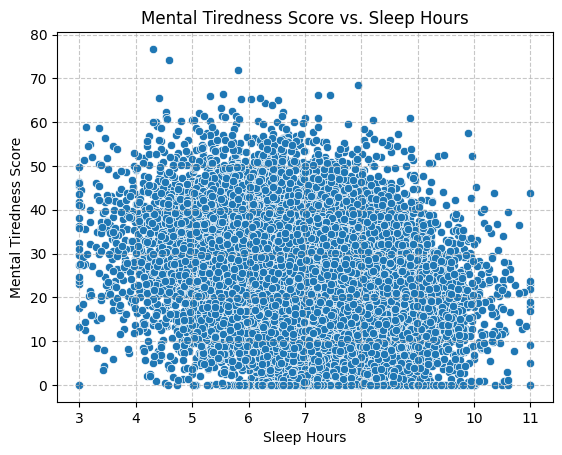

In [ ]:
sns.scatterplot(data=df, x='sleep_hours', y='mental_tiredness_score')
plt.title('Mental Tiredness Score vs. Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Mental Tiredness Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

OBSERVATION:

->The highest concentration of observations occurs between 5 and 8 sleep hours, where tiredness scores is between 10 to 60 range.

->A horizontal line at 0 incidates the no mental tiredness regardless of the duration of sleep

->Regradless of  duration of the sleep , the highest tiredness scores constant from 3 hours of sleep to 10 hours.

->This shows us sleep alone can't prevent mental tiredness , other factors like workload also play a role.

#Screen time vs mental tiredness

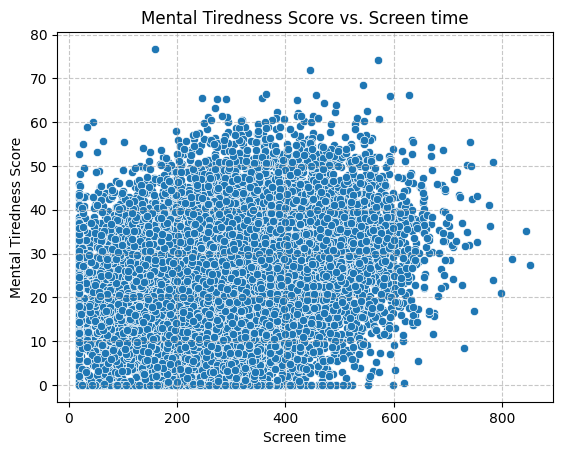

In [ ]:
sns.scatterplot(data=df, x='screen_time_min', y='mental_tiredness_score')
plt.title('Mental Tiredness Score vs. Screen time')
plt.xlabel('Screen time')
plt.ylabel('Mental Tiredness Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

OBSERVATION:

->The majority of data points are grouped between 200 and 400 minutes of screen time, where mental tiredness scores mostly range from 10 to 60.

->A few individual points reach peak tiredness scores near 65–80 across 100-600 screen times.

->Screen time alone does not predict mental tiredness, high screen time doesnot automatically mean high exhaustion.

#Relationship between work_type and mental_tiredness_score


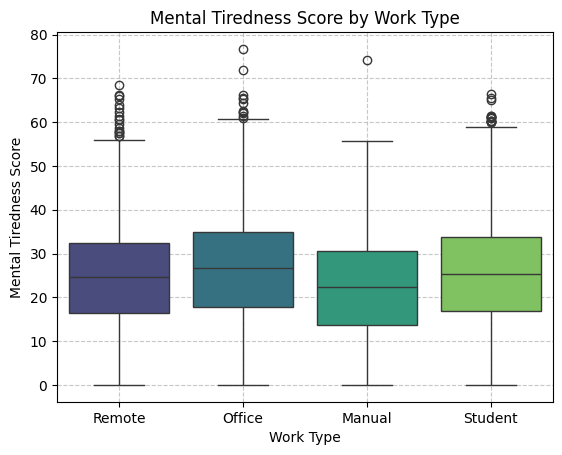

In [ ]:
sns.boxplot(data=df, x='work_type', y='mental_tiredness_score',hue='work_type', palette='viridis')
plt.title('Mental Tiredness Score by Work Type')
plt.xlabel('Work Type')
plt.ylabel('Mental Tiredness Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


OBSERVATION:

->Student and office shows a comparatively high mental tiredness and extreme outliers compared to manual and remote.

->As remote work type can be less stressful than of student and office, but some outliers could exist due to challenges like lack of work life boundaries.

->Manual work type includes both physical and mental work and the outlier could reflect in sudden change of shifts or tasks.


# Average Task Complexity by Mood

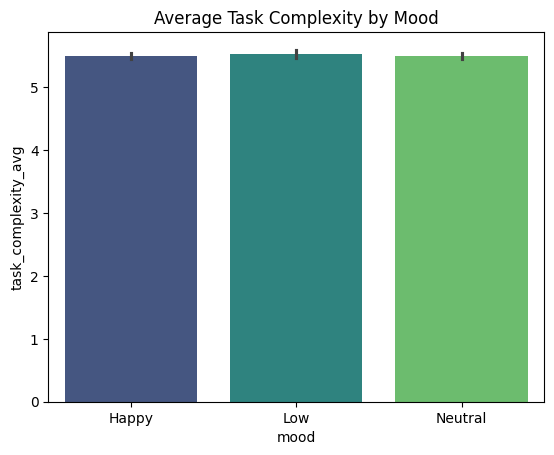

In [ ]:
sns.barplot(x='mood',y='task_complexity_avg',data=df,hue='mood', palette='viridis')
plt.title('Average Task Complexity by Mood')
plt.show()

OBSERVATION:

->They have a very low variation in averge task complexity between mood groups.

->Task complexity alone shows no visible relationship or variation with a person's mood in this dataset.

# Deep Sleep vs. Deep Work Scatter

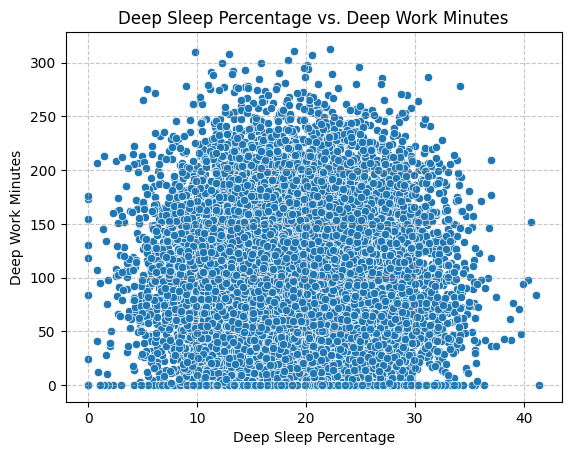

In [ ]:
sns.scatterplot(x='deep_sleep_pct',y='deep_work_min',data=df)
plt.title('Deep Sleep Percentage vs. Deep Work Minutes')
plt.xlabel('Deep Sleep Percentage')
plt.ylabel('Deep Work Minutes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

OBSERVATION:

->The majority of data points are between 10% to 30% deep sleep and 0 to 250 deep work minutes.

->A high percentage of deep sleep does not gaurantee higher deep work minutes

->At extreme values of deep sleep (below 5% or above 35%), deep work output consistently drops off, rarely exceeding 200 minutes.

->Deep sleep percentage does not show any correlation which make deep sleep percentage as low importance feature

#Multi-variate Analysis

# Mood Counts by Work Environment

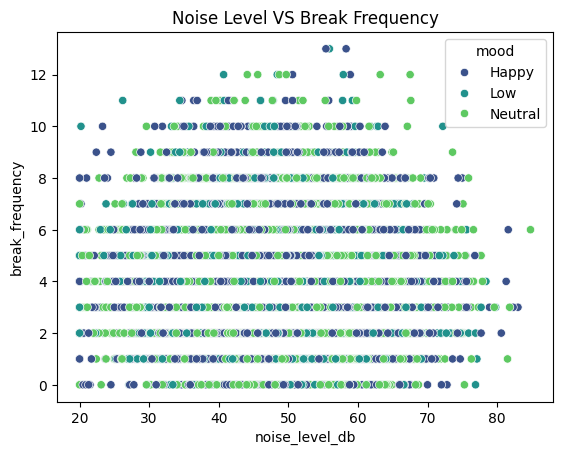

In [ ]:
sns.scatterplot(data=df, x='noise_level_db',y="break_frequency",hue='mood', palette='viridis')
plt.title('Noise Level VS Break Frequency')
plt.show()

OBSERVATION:


->Data points are arranged in horizontal lines parallel to integer values of break frequency.

->Noise level is majorly spread in between 25db to 75db.

->All three mood categories are uniformly scattered across nearly all noise levels and break frequencies.

->There is no visible correlation between environment noise level and how frequently someone takes breaks,people do not take more or fewer breaks simply because their environment is louder or quieter.

->Mood is unaffected by Noise/Break Interaction.



# Mental Tiredness by Work Env. & Mood

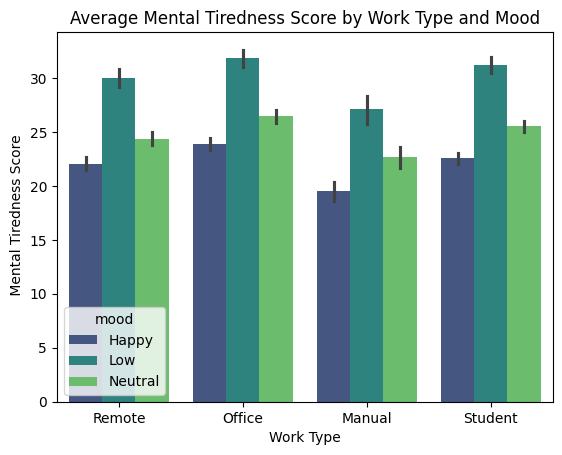

In [ ]:

sns.barplot(data=df, x='work_type', y='mental_tiredness_score', hue='mood', palette='viridis')
plt.title('Average Mental Tiredness Score by Work Type and Mood')
plt.ylabel(' Mental Tiredness Score')
plt.xlabel('Work Type')
plt.show()

OBSERVATION:

->In all the work type low mood consistently exhibit highest average mental tiredness scores.

->The Happy group records has the lowest mental tiredness scores across all work types.

->The Neutral mood group falls directly in between Happy and Low, maintaining a consistent average score.

->Mental tiredness is heavily influenced by mood rather than the work type.

#Correlation Analysis

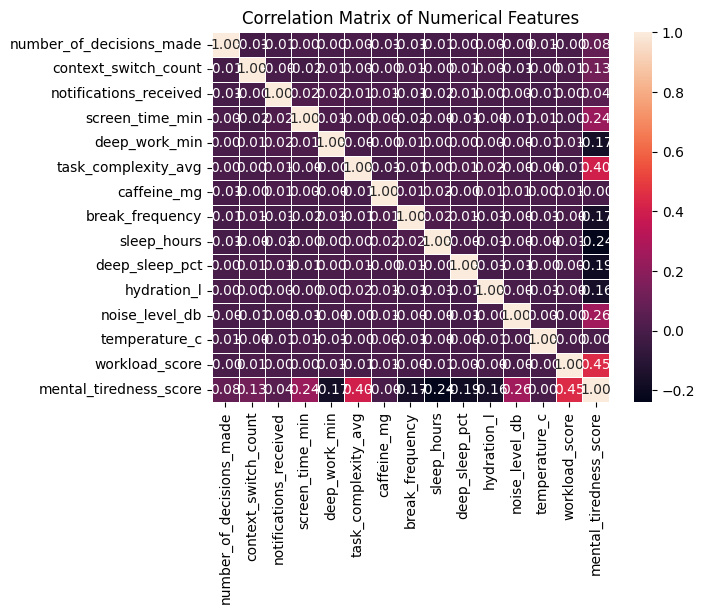

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

OBSERVATION:

-> Workload score and task complexity avg show the strongest positive correlation with target feature.

->Noise level and sleep hours and screen time in min exhibit moderate negative correlations with tiredness.

->Temperature,caffeine,notifications received shares zero linear relationship with the target variable.

#Checking for Outliers

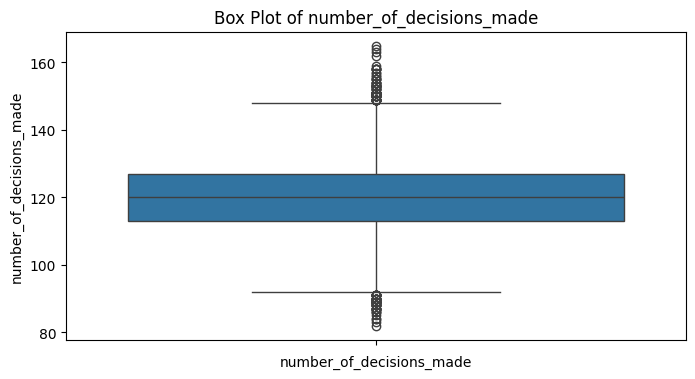

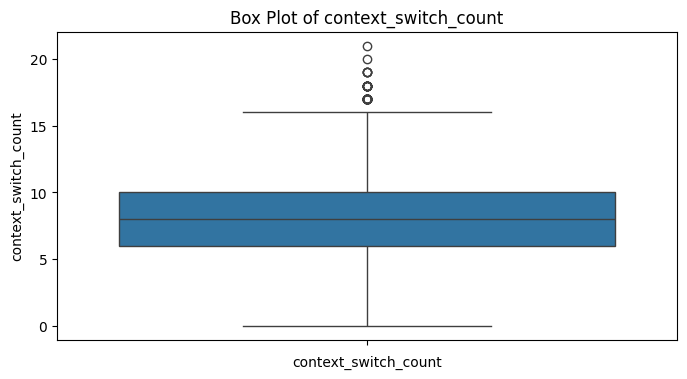

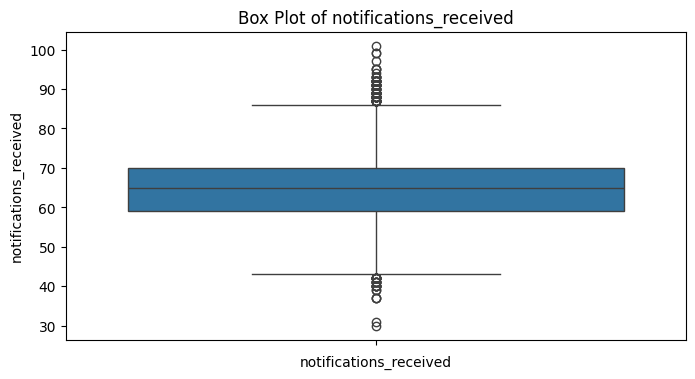

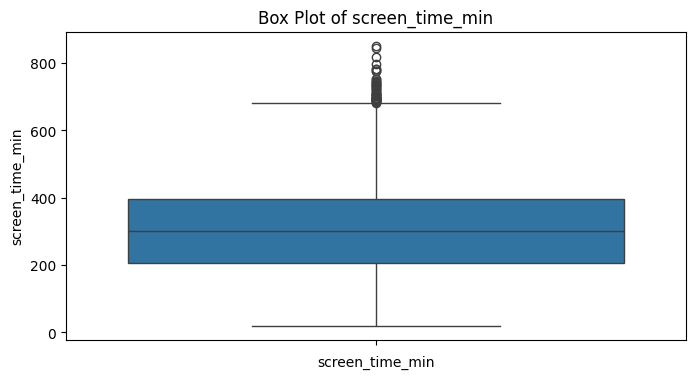

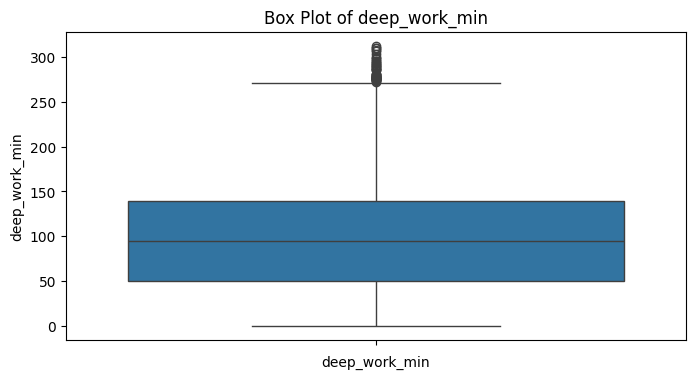

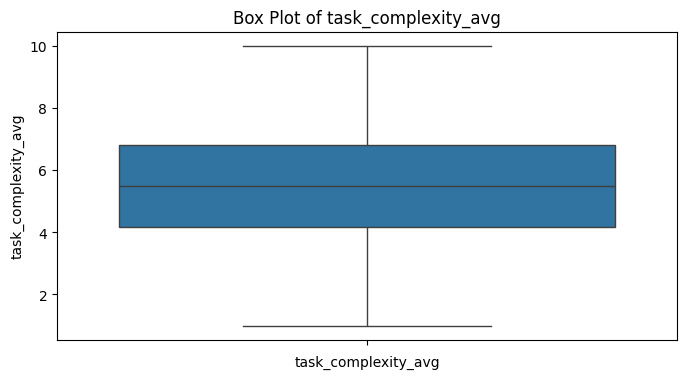

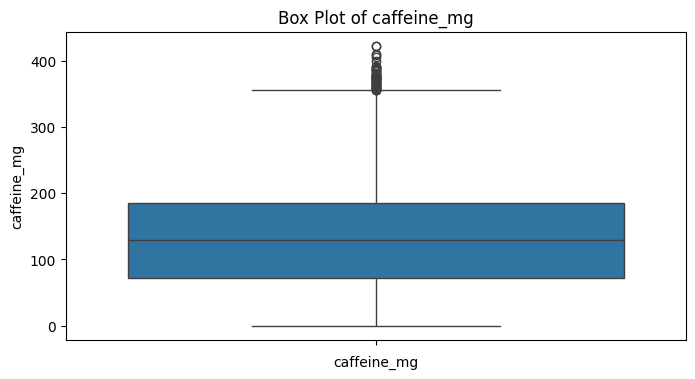

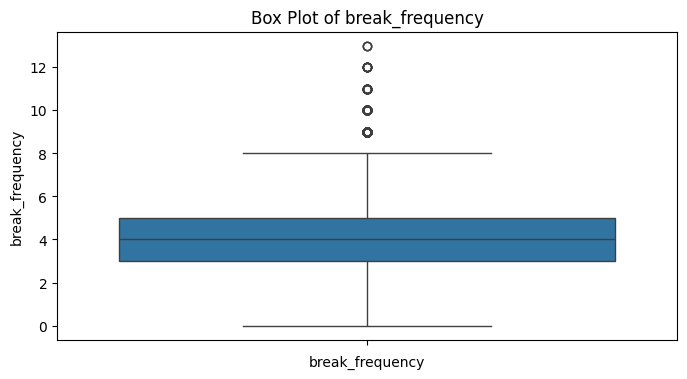

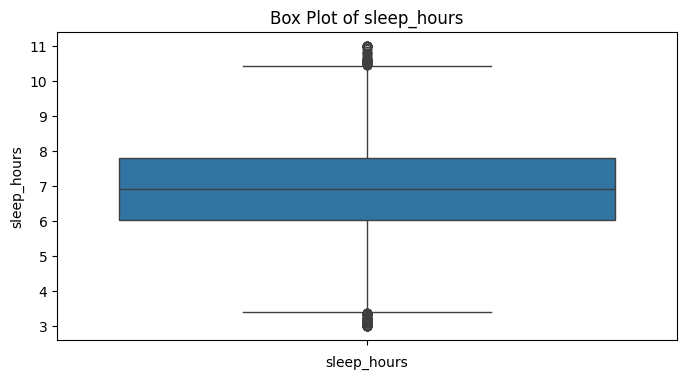

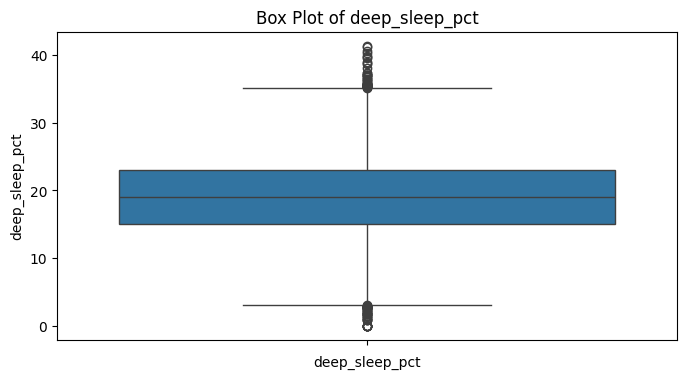

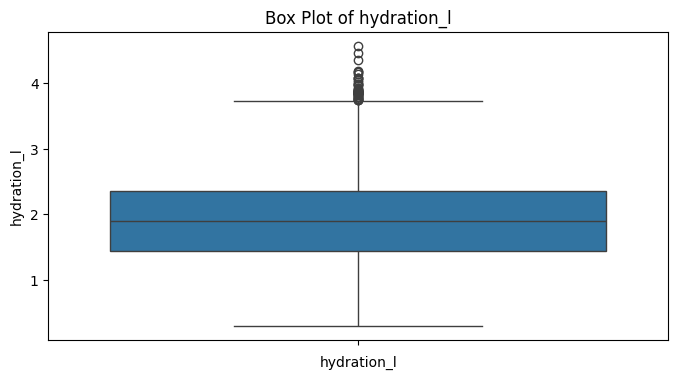

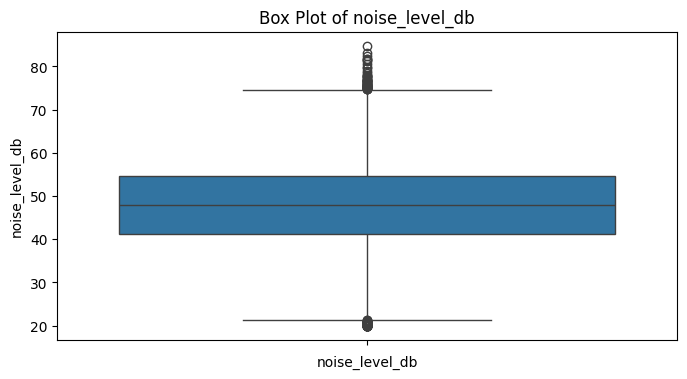

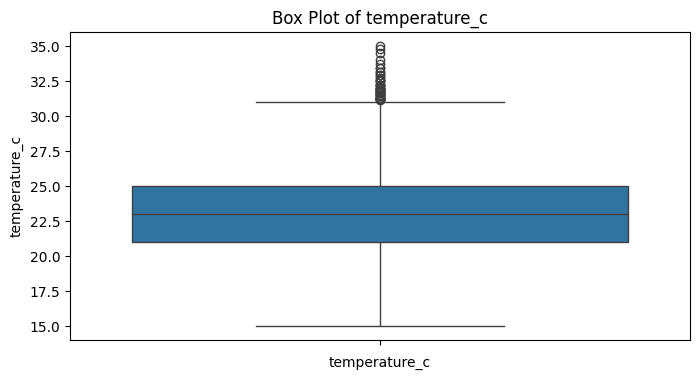

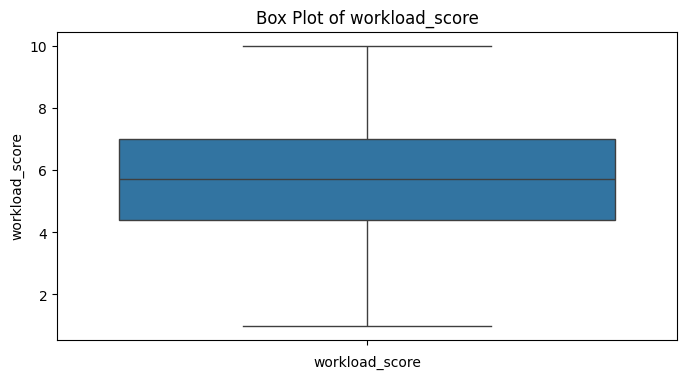

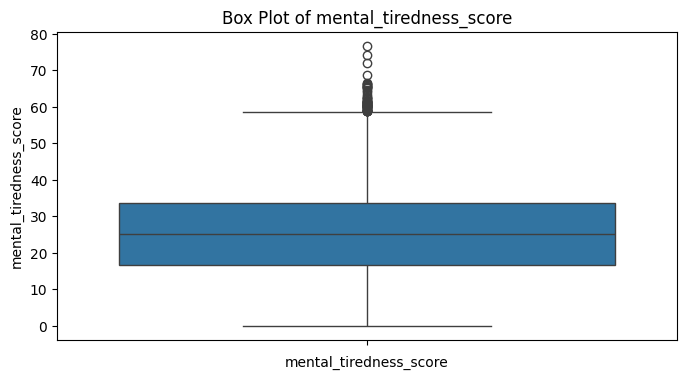

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns

for column in num_cols:
  plt.figure(figsize=(8,4))
  sns.boxplot(df[column])
  plt.title(f'Box Plot of {column}')
  plt.xlabel(column)
  plt.show()

#Splitting the data

In [ ]:
X=df.drop(columns=['mental_tiredness_score'])
y=df['mental_tiredness_score']

In [ ]:
# splitting the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 16)
(3000, 16)
(12000,)
(3000,)


In [ ]:
X_train.head(4)

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,noise_level_db,temperature_c,workload_score
9839,114,8,71,164.0,20.8,2.9,221.1,9,6.79,18.57,2.94,Neutral,Student,55.3,25.6,4.6
9680,112,15,71,398.1,245.2,6.6,81.8,2,6.43,15.39,2.99,Low,Remote,37.4,26.6,5.1
7093,117,9,67,336.4,126.7,4.6,80.6,6,7.20,20.38,2.38,Neutral,Office,55.9,20.2,5.9
11293,132,7,64,314.5,58.2,9.8,193.5,7,7.33,13.99,1.39,Happy,Student,45.5,25.6,6.5


#Datapreprocessing

In [ ]:
# datapreprocessing
from sklearn.preprocessing import RobustScaler,OrdinalEncoder

# let's use columntransformer
from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer(transformers=[('t1',OrdinalEncoder(),[11,12]),
                                            ('t2',RobustScaler(),[0,1,2,3,4,5,6,7,8,9,10,13,14,15])])

# fit_transformer on X_train
X_train_trans=transformer.fit_transform(X_train)

# transform on testdata
X_test_trans=transformer.transform(X_test)

print(X_train_trans.shape)
print(X_test_trans.shape)

(12000, 16)
(3000, 16)


In [ ]:
X_train_trans=pd.DataFrame(X_train_trans,columns=X_train.columns)
X_test_trans=pd.DataFrame(X_test_trans,columns=X_test.columns)

#Saving the transformed file for further usage

In [ ]:
X_train_trans.to_csv("X_Train_Trans.csv",index=False)
X_test_trans.to_csv("X_Test_Trans.csv",index=False)
y_train.to_csv("y_Train.csv",index=False)
y_test.to_csv("y_test.csv",index=False)